Selected features: ['MedInc', 'AveOccup', 'Latitude', 'Longitude']
Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 30}
Mean Squared Error: 0.3303
R2 Score: 0.7479
Cross-validation R2 scores: [0.60120334 0.64212477 0.67625581 0.52365597 0.63065213]
Average CV R2 score: 0.6148 (+/- 0.1030)


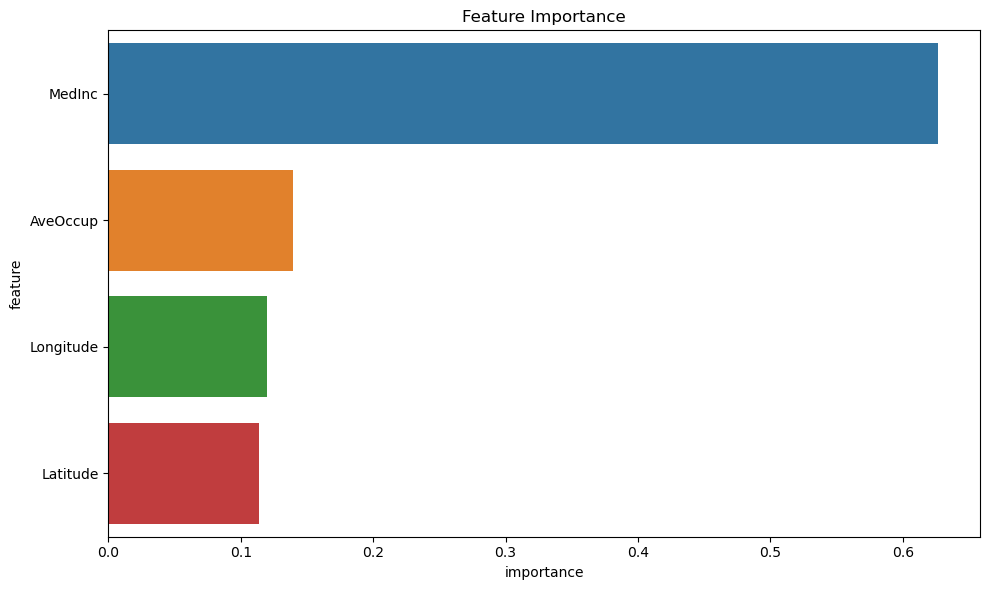

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Step 1: Load and preprocess data
# Load California Housing dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='MedHouseVal')

# Handle missing values (California dataset has none, but included for generality)
X = X.fillna(X.mean())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Step 2: Feature selection
# Use GradientBoostingRegressor for feature importance
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_scaled, y)

# Select features based on importance
selector = SelectFromModel(gbr, threshold='median')
selector.fit(X_scaled, y)

# Get selected feature names
selected_features = X_scaled.columns[selector.get_support()].tolist()
print(f"Selected features: {selected_features}")

# Filter dataset to selected features
X_selected = X_scaled[selected_features]

# Step 3: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# Step 4: Hyperparameter tuning
# Define parameter grid
param_grid = {
    'n_estimators': [10, 20, 30],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize model
gbr = GradientBoostingRegressor(random_state=42)

# Perform grid search
grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# Get best model
best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

# Step 5: Model training and evaluation
# Make predictions
y_pred = best_model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

# Cross-validation
cv_scores = cross_val_score(best_model, X_selected, y, cv=5, scoring='r2')
print(f"Cross-validation R2 scores: {cv_scores}")
print(f"Average CV R2 score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Step 6: Feature importance visualization
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()